# 2D Structure Function Data with SWOT

This example will guide you through each step necessary to compute various SFs from SWOT Data

$\textbf{General procedure}:$


    1 -  Load a synthetic data based on SWOT dataset. SWOT data can be downloaded from AVISO or from podaac NASA https://podaac.jpl.nasa.gov/SWOT 
    2 -  Compute various Isotropic SFs
    3 -  Plot These Isotropic SFs
    4 -  Estimate cascade rates
    5 -  Plot cascade rates estimations

$\textbf{Motivation:}$ This example reveals an application of structure function computation through pyturbo on SWOT data. While traditional spectral methods using FFT have been widely applied to SWOT observations, they face significant limitations with gappy data—requiring at least 70% data completeness and rejecting time series with gaps exceeding 5 consecutive days (Fouchet et al., 2025). Structure functions offer a robust alternative that can handle irregular sampling patterns inherent in satellite observations. Following recent advances in separating unbalanced submesoscale motions from internal gravity waves using vertical scale decomposition (Cao et al., 2023), we apply the cascade rate estimation method developed by Pearson et al. (2021), which uses second-order advective structure functions to diagnose energy and enstrophy dissipation rates in anisotropic turbulence.

$\textbf{References:}$

Fouchet, E., Benkiran, M., Le Traon, P-Y., & Remy, E. (2025). Comparison of a global high-resolution ocean data assimilation system with SWOT observations. Frontiers in Marine Science, 12:1563934. https://doi.org/10.3389/fmars.2025.1563934

Cao, H., Fox-Kemper, B., Jing, Z., Song, X., & Liu, Y. (2023). Towards the upper-ocean unbalanced submesoscale motions in the Oleander observations. Journal of Physical Oceanography, 53(4), 1123-1138. https://doi.org/10.1175/JPO-D-22-0134.1

Pearson, B. C., Pearson, J. L., & Fox-Kemper, B. (2021). Advective structure functions in anisotropic two-dimensional turbulence. Journal of Fluid Mechanics, 916, A48. https://doi.org/10.1017/jfm.2021.247

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load SWOT Dataset

In [2]:
ds = xr.open_dataset('example_data/subset_swot.nc')
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 531, x: 69)
Coordinates:
    x        (y, x) float64 293kB ...
    y        (y, x) float64 293kB ...
Data variables:
    u        (y, x) float64 293kB ...
    v        (y, x) float64 293kB ...
    adv_u    (y, x) float64 293kB ...
    adv_v    (y, x) float64 293kB ...

# Quick Plot 

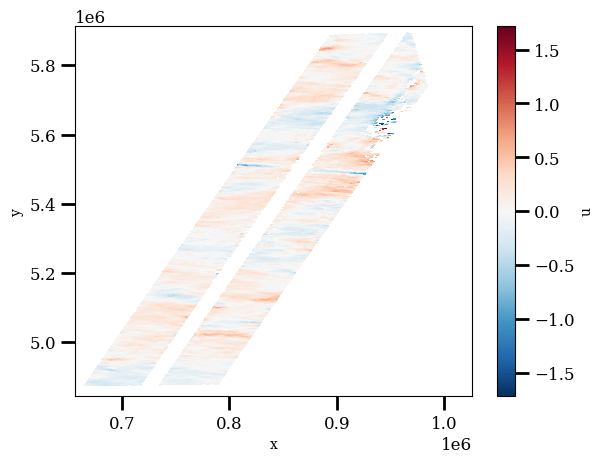

In [3]:
ds.u.plot()

# Compute third order Isotropic Longitudinal SF

In [4]:
%%time

bin_r = np.logspace(np.log10(2000.), np.log10(1.0e6), 11)

bins = {
    'r': bin_r,
}
iso_sf_lon = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=3,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':128,'x':69},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.1,
    window_size_r=8,
    window_size_theta=10,
    backend='loky'
)

Dimensions ('y', 'x') are already in the expected order
Dimension x has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
Using bootsize: {'y': 128, 'x': 69}
Bootstrappable dimensions: ['y']
Single bootstrappable dimension (y). Using spacings: [1, 2, 4]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 3


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 20 bootstraps
Processing spacing 2 with 20 bootstraps
Processing spacing 4 with 20 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 462449
Bins with points: 10/10
Marked 9 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 1 unconverged bins
Grouped unconverged bins into 1 groups

Processing 1 bins with step size 40 in density quartile 0

Iteration 2 - 1 unconverged bins
Grouped unconverged bins into 1 groups

Processing 1 bins with step size 40 in density quartile 0

Iteration 3 - 1 unconverged bins
G

# Plot third order Isotropic Longitudinal SF

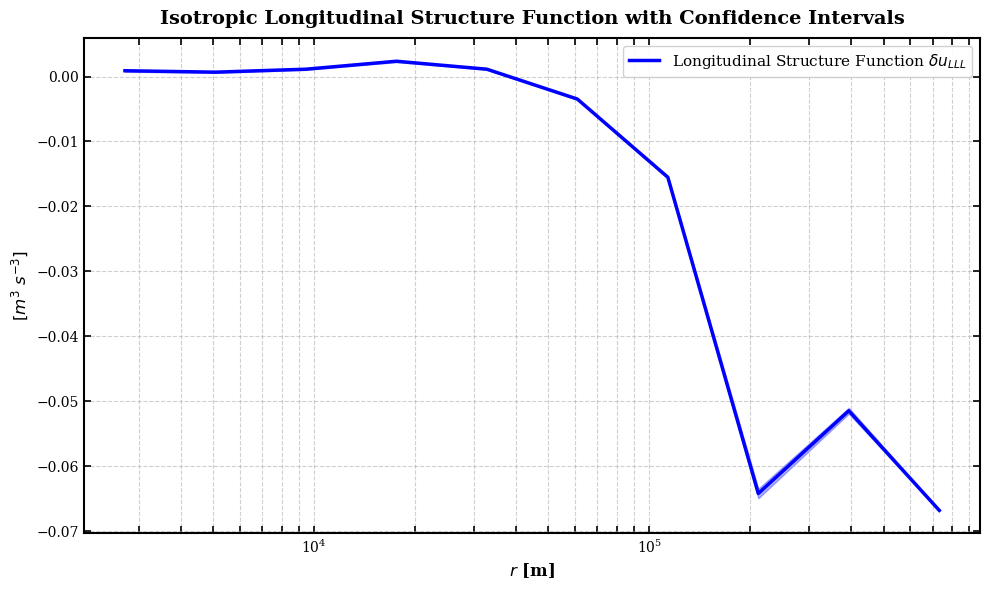

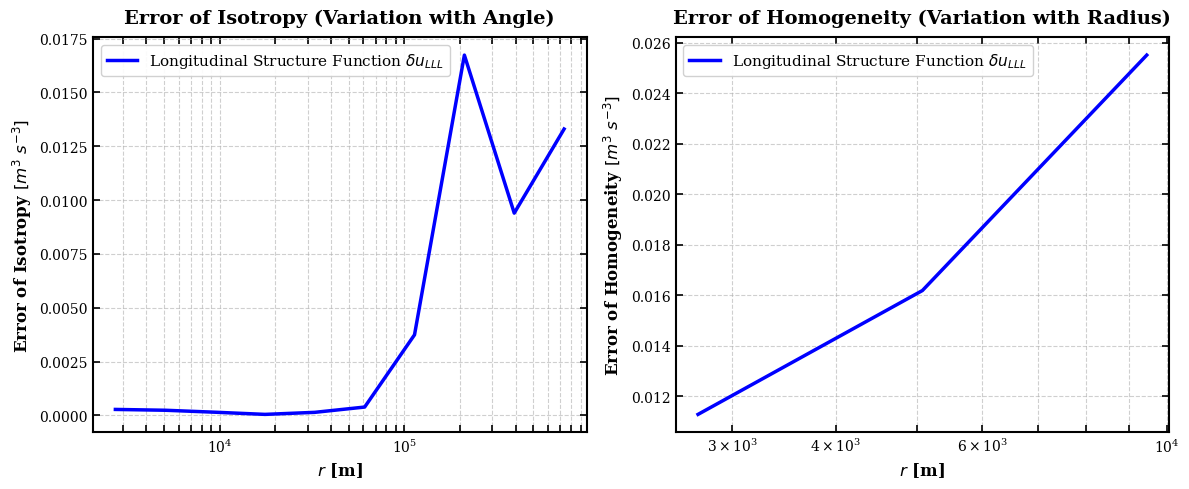

Exception ignored in: <function ResourceTracker.__del__ at 0x70f573b8ab60>
Traceback (most recent call last):
  File "/home/aayouche/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/aayouche/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/aayouche/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x79a55d982b60>
Traceback (most recent call last):
  File "/home/aayouche/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/aayouche/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/aayouche/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function Resour

In [10]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_lon.r, iso_sf_lon.sf, 'b-', linewidth=2.5, label='Longitudinal Structure Function'+' '+'$\delta u_{LLL}$')

plt.fill_between(iso_sf_lon.r, 
                iso_sf_lon.ci_lower, 
                iso_sf_lon.ci_upper, 
                alpha=0.3, color='blue')


# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$[m^{3}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Longitudinal Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_lon.r, iso_sf_lon.error_isotropy, 'b-', linewidth=2.5,label='Longitudinal Structure Function'+' '+'$\delta u_{LLL}$')

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m^{3}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_lon.r_subset, iso_sf_lon.error_homogeneity, 'b-', linewidth=2.5,label='Longitudinal Structure Function'+' '+'$\delta u_{LLL}$')
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m^{3}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

# Compute advective SF

In [6]:
%%time
bin_r = np.logspace(np.log10(2000.), np.log10(1.0e6), 11)

bins = {
    'r': bin_r,
}
iso_sf_adv = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v","adv_u","adv_v"],
    order=1,
    bins=bins,
    fun='advective',
    bootsize={'y':128,'x':69},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-7,
    window_size_r=8,
    window_size_theta=10,
    backend='loky'
)

Dimensions ('y', 'x') are already in the expected order
Dimension x has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
Using bootsize: {'y': 128, 'x': 69}
Bootstrappable dimensions: ['y']
Single bootstrappable dimension (y). Using spacings: [1, 2, 4]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: advective
Variables: ['u', 'v', 'adv_u', 'adv_v'], Order: 1


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 20 bootstraps
Processing spacing 2 with 20 bootstraps
Processing spacing 4 with 20 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 446030
Bins with points: 10/10
Marked 5 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 5 unconverged bins
Grouped unconverged bins into 2 groups

Processing 2 bins with step size 40 in density quartile 1

Processing 3 bins with step size 40 in density quartile 0

Iteration 2 - 5 unconverged bins
Grouped unconverged bins into 2 groups

Processing 2 bins w

# Plot Advective SF

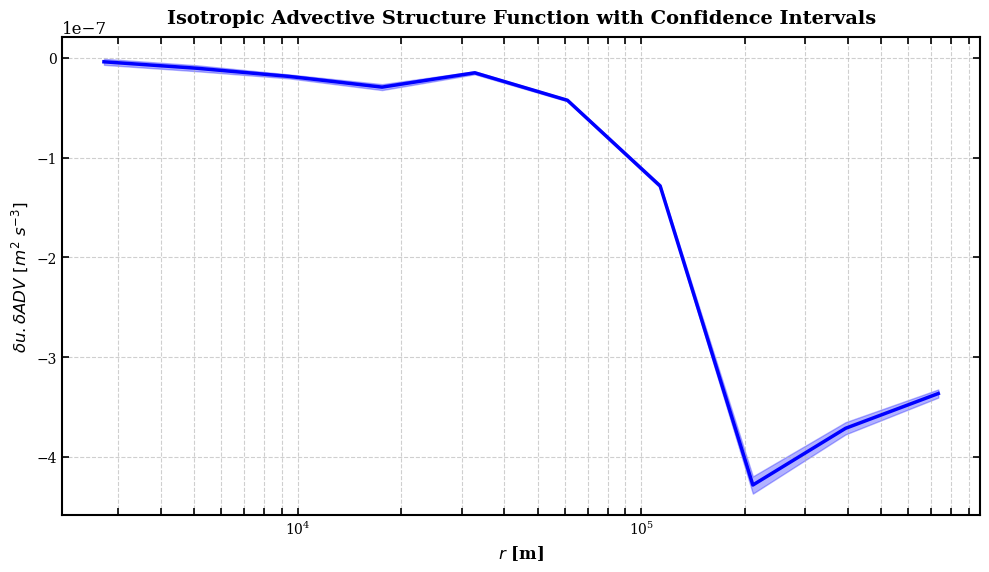

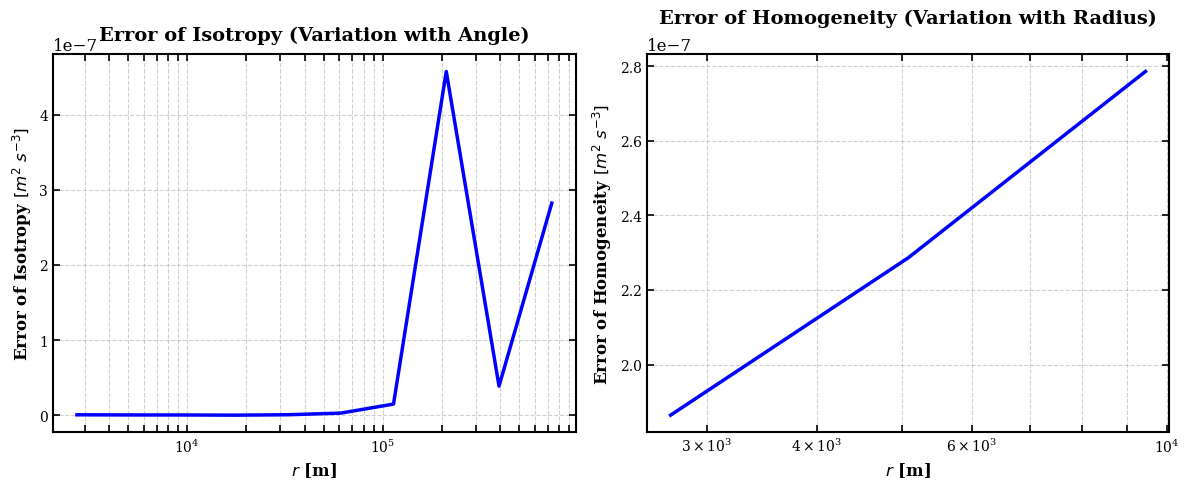

In [7]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_adv.r, iso_sf_adv.sf, 'b-', linewidth=2.5)

plt.fill_between(iso_sf_adv.r, 
                iso_sf_adv.ci_lower, 
                iso_sf_adv.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta u.\delta ADV~[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Advective Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_adv.r, iso_sf_adv.error_isotropy, 'b-', linewidth=2.5)

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_adv.r_subset, iso_sf_adv.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

# Estimate Cascade rates

In 2D quasi-geostrophy, the third order longitudinal structure function $\delta u_{LLL}$ and the advective structure function $\delta u . \delta ADV$ are related to inverse cascade rates:

$\rm \epsilon = -2\delta u_{LLL}/3r$

$\rm \epsilon = -\delta u.\delta ADV/2$

In [8]:
eps_lon = -2*iso_sf_lon.sf/(3*iso_sf_lon.r)
eps_adv = -iso_sf_adv.sf/2.0


# Plot Cascade rates

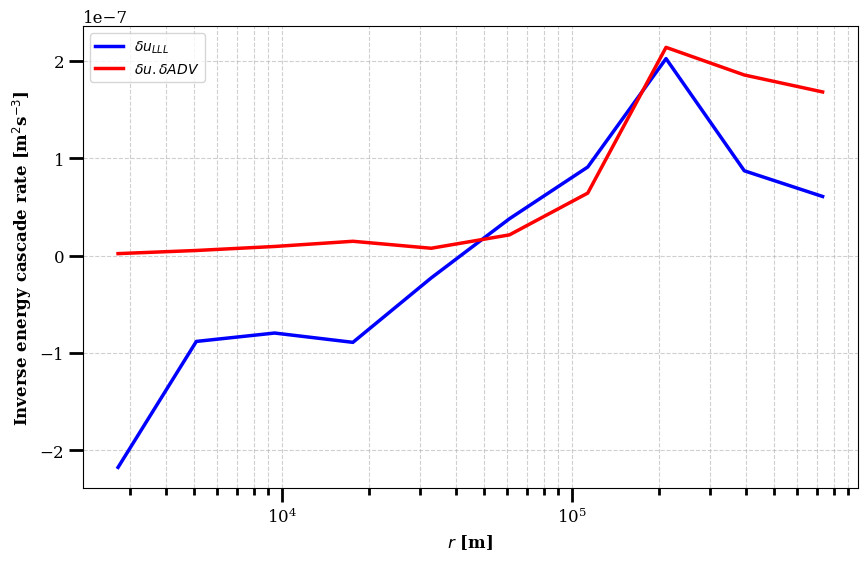

In [9]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_adv.r, eps_lon, 'b-', linewidth=2.5,label=r'$\delta u_{LLL}$')
plt.plot(iso_sf_adv.r, eps_adv, 'r-', linewidth=2.5,label=r'$\delta u.\delta ADV$')



# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r"Inverse energy cascade rate [m$^2$s$^{-3}$]", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
